Parte 1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge

In [101]:
df = pd.read_csv("regressao/train.csv")

In [102]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,score
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,6,5.67
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,4,5.33
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,10,8.33
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,2,14.67
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,4,8.67


In [103]:
df.shape

(395, 31)

In [104]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'score'],
      dtype='str')

In [105]:
df.dtypes

school            str
sex               str
age             int64
address           str
famsize           str
Pstatus           str
Medu            int64
Fedu            int64
Mjob              str
Fjob              str
reason            str
guardian          str
traveltime      int64
studytime       int64
failures        int64
schoolsup         str
famsup            str
paid              str
activities        str
nursery           str
higher            str
internet          str
romantic          str
famrel          int64
freetime        int64
goout           int64
Dalc            int64
Walc            int64
health          int64
absences        int64
score         float64
dtype: object

In [106]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
score         0
dtype: int64

In [107]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,score
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.679139
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.696912
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.330000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.330000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,10.670000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.330000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.330000


In [108]:
df["school"].value_counts()

school
GP    349
MS     46
Name: count, dtype: int64

In [109]:
df["Mjob"].value_counts()

Mjob
other       141
services    103
at_home      59
teacher      58
health       34
Name: count, dtype: int64

In [110]:
df.select_dtypes(include="str").columns

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='str')

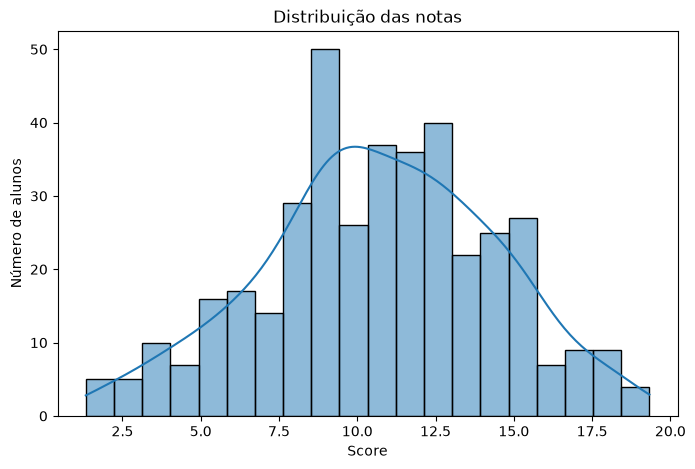

In [111]:
plt.figure(figsize=(8, 5))
sns.histplot(df["score"], bins=20, kde=True)
plt.xlabel("Score")
plt.ylabel("Número de alunos")
plt.title("Distribuição das notas")
plt.show()

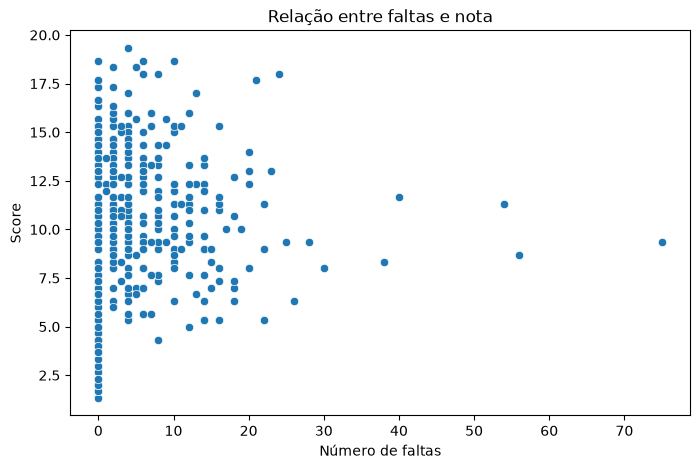

In [112]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="absences", y="score")
plt.xlabel("Número de faltas")
plt.ylabel("Score")
plt.title("Relação entre faltas e nota")
plt.show()

In [113]:
df.select_dtypes(include="number").corr()["score"].sort_values(ascending=False)

score         1.000000
Medu          0.224220
Fedu          0.175822
studytime     0.134546
famrel        0.021631
freetime      0.003773
absences     -0.005978
Dalc         -0.072502
health       -0.080333
Walc         -0.088042
traveltime   -0.128141
age          -0.134566
goout        -0.154530
failures     -0.375702
Name: score, dtype: float64

In [114]:
corr_score = (
    df.corr(method="spearman", numeric_only=True)["score"]
    .drop("score")
    .sort_values()
)

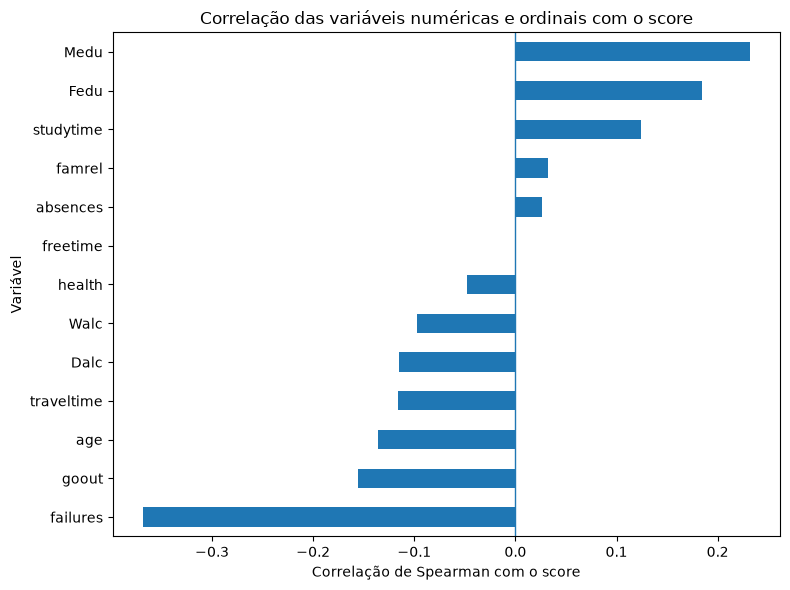

In [115]:
plt.figure(figsize=(8, 6))

corr_score.plot(kind="barh")

plt.axvline(0, linewidth=1)
plt.xlabel("Correlação de Spearman com o score")
plt.ylabel("Variável")
plt.title("Correlação das variáveis numéricas e ordinais com o score")

plt.tight_layout()
plt.show()

In [116]:
df["sex"].value_counts()

sex
F    208
M    187
Name: count, dtype: int64

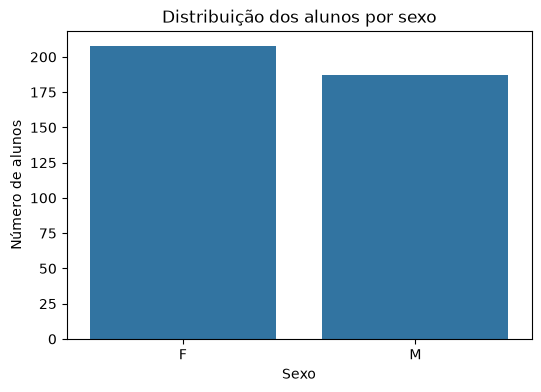

In [117]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="sex")
plt.xlabel("Sexo")
plt.ylabel("Número de alunos")
plt.title("Distribuição dos alunos por sexo")
plt.show()

In [118]:
X = df.drop(columns="score")
y = df["score"]
X.shape, y.shape

((395, 30), (395,))

In [119]:
from sklearn.model_selection import train_test_split

In [120]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((316, 30), (79, 30), (316,), (79,))

In [121]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [122]:
categorical_features = [
    "school",
    "sex",
    "address",
    "famsize",
    "Pstatus",
    "Mjob",
    "Fjob",
    "reason",
    "guardian",
    "schoolsup",
    "famsup",
    "paid",
    "activities",
    "nursery",
    "higher",
    "internet",
    "romantic"
]

numeric_features = [
    col for col in X.columns
    if col not in categorical_features
]
len(categorical_features), len(numeric_features)

(17, 13)

In [123]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_train_processed.shape, X_val_processed.shape

((316, 56), (79, 56))

In [124]:
from sklearn.linear_model import LinearRegression

In [125]:
model_lr = LinearRegression()

In [126]:
model_lr.fit(X_train_processed, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](56,)","[-0.27, 0.27,-0.56,...,-0.01,-0.2 , 0.25]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,10.4
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,56
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(39)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](56,)","[28.27,25.83,21.03,..., 0. , 0. , 0. ]"


In [127]:
y_pred_lr = model_lr.predict(X_val_processed)

In [128]:
from sklearn.metrics import root_mean_squared_error

In [129]:
rmse_lr = root_mean_squared_error(y_val, y_pred_lr)
rmse_lr

3.3749658534076996

In [130]:
from sklearn.ensemble import RandomForestRegressor

In [131]:
model_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)
model_rf.fit(X_train_processed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [132]:
y_pred_rf = model_rf.predict(X_val_processed)

In [133]:
y_pred_rf = model_rf.predict(X_val_processed)
rmse_rf = root_mean_squared_error(y_val, y_pred_rf)

print("RMSE Random Forest:", rmse_rf)

RMSE Random Forest: 3.2168397251581937


In [134]:
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train_processed, y_train)
y_pred_ridge = model_ridge.predict(X_val_processed)
rmse_ridge = root_mean_squared_error(y_val, y_pred_ridge)

print("RMSE Ridge:", rmse_ridge)

RMSE Ridge: 3.372275290756077


In [135]:
resultados = pd.DataFrame({
    "Modelo": [
        "Regressão Linear",
        "Ridge",
        "Random Forest"
    ],
    "RMSE": [
        rmse_lr,
        rmse_ridge,
        rmse_rf
    ]
})

resultados = resultados.sort_values("RMSE")
resultados

,Modelo,RMSE
2,Random Forest,3.216840
1,Ridge,3.372275
0,Regressão Linear,3.374966


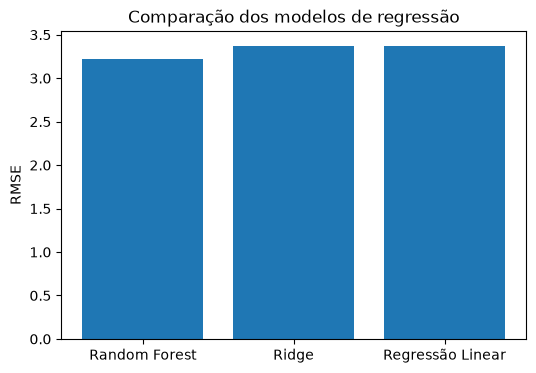

In [136]:
plt.figure(figsize=(6,4))

plt.bar(resultados["Modelo"], resultados["RMSE"])

plt.ylabel("RMSE")
plt.title("Comparação dos modelos de regressão")

plt.show()

In [ ]:
## Os modelos de Regressão Linear e Random Forest foram avaliados usando o RMSE (Root Mean Squared Error) como métrica de desempenho. A Regressão Linear obteve um RMSE de 3,375, enquanto o Random Forest teve um RMSE de 3,217. Como um RMSE menor indica previsões mais precisas, o Random Forest apresentou o melhor resultado e foi escolhido como o modelo final.

In [156]:
X_processed = preprocessor.fit_transform(X)
X_test_processed = preprocessor.transform(df)

modelo_final = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

modelo_final.fit(X_processed, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [157]:
predicoes = modelo_final.predict(X_test_processed)

predicoes

array([12.728  , 10.66305,  5.8173 , 11.743  , 12.6278 , 10.39115,
       10.0076 , 10.39325, 11.2462 , 10.1728 ,  9.36955, 11.84275,
       10.5327 ,  9.78925, 10.8347 ,  9.7309 , 10.36395, 11.4592 ,
        9.90955, 10.2229 , 10.67975, 10.8408 , 10.6129 , 10.23105,
       12.59115, 11.62775, 10.60435,  8.83315,  9.70625, 11.58165,
       10.55235, 10.5663 , 11.51   , 10.86835,  8.8041 , 11.14435,
       10.4912 ,  9.5994 ,  4.364  , 11.5563 ])

In [158]:
submission = pd.DataFrame({
    "id": range(len(predicoes)),
    "score": predicoes
})

submission.head()

,id,score
0,0,12.72800
1,1,10.66305
2,2,5.81730
3,3,11.74300
4,4,12.62780


In [161]:
import pandas as pd

# 1. Ler o TESTE REAL
df_test = pd.read_csv("regressao/test.csv")

print("TESTE:")
print(df_test.shape)
print(df_test.head())
print(df_test.columns.tolist())

# 2. Aplicar o preprocessor SEM fit
X_test_processed = preprocessor.transform(df_test)

# 3. Fazer as previsões
predicoes = modelo_final.predict(X_test_processed)

# 4. Criar submissão
submission = pd.DataFrame({
    "id": df_test.index,
    "score": predicoes
})

# 5. Salvar
submission.to_csv("regressao/submission.csv", index=False)

# 6. Conferir
print("\nSUBMISSION:")
print(submission)
print("\nShape:", submission.shape)
print("\nColunas:", submission.columns.tolist())
print("\nNaN:")
print(submission.isna().sum())

TESTE:
(40, 30)
  school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0     GP   M   16       U     LE3       T     2     2     other  services   
1     GP   F   15       U     LE3       T     2     1     other     other   
2     GP   M   16       U     GT3       A     1     4  services   teacher   
3     GP   F   16       U     LE3       T     4     4     other  services   
4     GP   F   18       R     GT3       T     3     3   teacher     other   

   ... higher internet  romantic  famrel  freetime goout Dalc Walc health  \
0  ...    yes      yes       yes       1         5     3    1    1      5   
1  ...    yes       no        no       5         5     3    2    1      3   
2  ...     no      yes        no       5         3     2    1    2      1   
3  ...    yes      yes        no       4         2     4    1    3      4   
4  ...    yes       no       yes       2         1     3    1    1      1   

  absences  
0        6  
1        6  
2        0  
3     

Parte 2

In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [164]:
df = pd.read_csv("classiicacao/train2.csv")

print(df.shape)
df.head()

(569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [165]:
df.info()

print("\nValores nulos:")
print(df.isnull().sum())

print("\nDescrição estatística:")
display(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


diagnosis
B    357
M    212
Name: count, dtype: int64


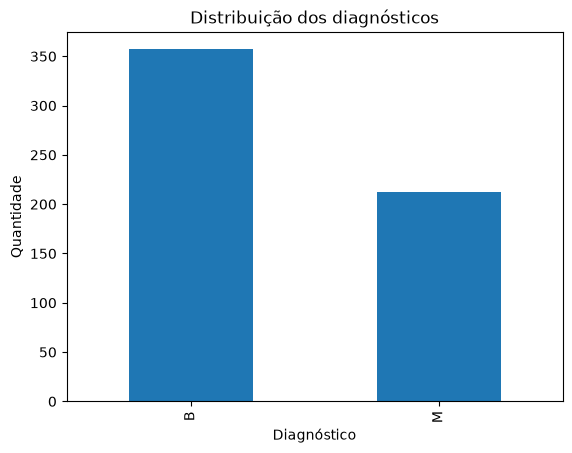

In [166]:
print(df["diagnosis"].value_counts())

df["diagnosis"].value_counts().plot(
    kind="bar",
    title="Distribuição dos diagnósticos"
)

plt.xlabel("Diagnóstico")
plt.ylabel("Quantidade")
plt.show()

In [167]:
df_corr = df.copy()

df_corr["diagnosis"] = df_corr["diagnosis"].map({
    "B":0,
    "M":1
})

correlacoes = (
    df_corr.corr()["diagnosis"]
    .sort_values(ascending=False)
)

print(correlacoes.head(10))

diagnosis               1.000000
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
Name: diagnosis, dtype: float64


In [168]:
X = df.drop(columns="diagnosis")
y = df["diagnosis"]

In [169]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


In [170]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [171]:
log_model = LogisticRegression(random_state=42, max_iter=500)

log_model.fit(X_train_scaled, y_train)

pred_log = log_model.predict(X_test_scaled)

In [172]:
acc_log = accuracy_score(y_test, pred_log)

print("Acurácia:", acc_log)

print(classification_report(y_test, pred_log))

Acurácia: 0.9649122807017544
              precision    recall  f1-score   support

           B       0.96      0.99      0.97        72
           M       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [173]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

pred_rf = rf_model.predict(X_test)

In [174]:
acc_rf = accuracy_score(y_test, pred_rf)

print("Acurácia Random Forest:", acc_rf)

print(classification_report(y_test, pred_rf))

Acurácia Random Forest: 0.9649122807017544
              precision    recall  f1-score   support

           B       0.95      1.00      0.97        72
           M       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



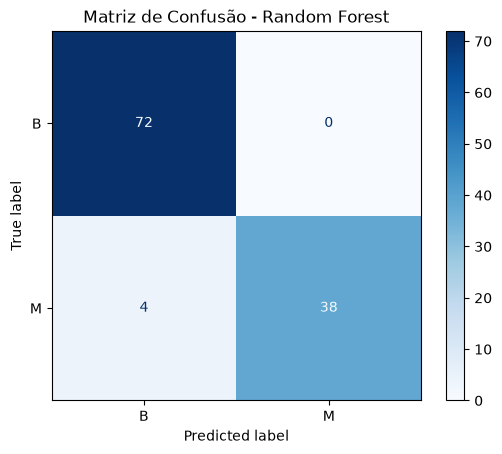

[[72  0]
 [ 4 38]]


In [175]:
cm = confusion_matrix(y_test, pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_model.classes_
)

disp.plot(cmap="Blues")

plt.title("Matriz de Confusão - Random Forest")
plt.show()

print(cm)

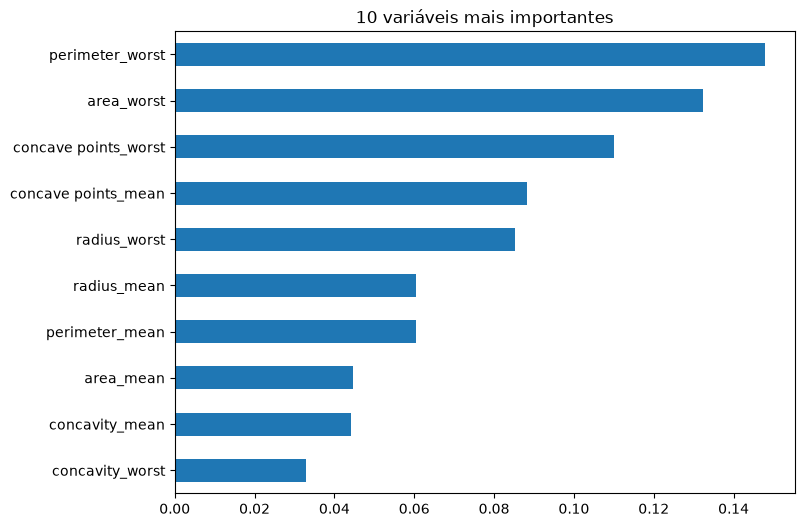

perimeter_worst         0.147912
area_worst              0.132269
concave points_worst    0.110114
concave points_mean     0.088200
radius_worst            0.085116
radius_mean             0.060554
perimeter_mean          0.060465
area_mean               0.044701
concavity_mean          0.044091
concavity_worst         0.032828
dtype: float64


In [176]:
importancias = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,6))

importancias.head(10).sort_values().plot(kind="barh")

plt.title("10 variáveis mais importantes")
plt.show()

print(importancias.head(10))

In [178]:
df_test = pd.read_csv("classiicacao/test2.csv")

print(df_test.shape)
df_test.head()

(40, 30)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,12.645,16.44,74.07,747.7,0.08951,0.05046,0.117298,0.027133,0.1434,0.05830,...,12.828,12.71,87.79,864.2,0.11189,0.10726,0.147406,0.072555,0.2096,0.07857
1,13.292,19.56,80.11,557.4,0.10111,0.15711,0.137410,0.082961,0.1646,0.07370,...,12.519,18.50,84.44,622.9,0.14560,0.40012,0.329984,0.165993,0.2506,0.14659
2,10.725,14.12,53.98,254.4,0.11683,0.11149,0.043338,0.018233,0.1690,0.07969,...,9.929,13.97,71.24,201.1,0.14530,0.32290,0.297290,0.090397,0.2848,0.14177
3,14.202,30.46,98.15,560.3,0.10003,0.11007,0.238674,0.154468,0.1708,0.06092,...,16.473,31.26,84.63,1367.0,0.15024,0.33261,0.745683,0.220761,0.2391,0.08430
4,11.747,19.00,78.87,442.1,0.10517,0.08937,0.039884,0.020402,0.1918,0.06117,...,12.838,23.18,91.74,515.7,0.12267,0.22598,0.057302,0.092982,0.2614,0.08512


In [182]:
predicoes = rf_model.predict(df_test)

submission = pd.DataFrame({
    "id": range(len(df_test)),
    "diagnosis": predicoes
})

submission.to_csv(
    "classiicacao/submission.csv",
    index=False
)

submission.head()

,id,diagnosis
0,0,B
1,1,B
2,2,B
3,3,M
4,4,B


In [185]:
sample = pd.read_csv("classiicacao/submission.csv")

print(sample.head())

   id diagnosis
0   0         B
1   1         B
2   2         B
3   3         M
4   4         B


In [193]:
import pandas as pd

df_test = pd.read_csv("classiicacao/test2.csv")

predicoes = rf_model.predict(df_test)

submission = pd.DataFrame({
    "id": range(len(df_test)),
    "diagnosis": predicoes
})

submission.to_csv("classiicacao/submission.csv", index=False)